In [3]:
import pandas as pd

df = pd.read_csv("TelecomX_limpio.csv")
df.head()

,ID_Cliente,Abandono,Genero,AdultoMayor,TienePareja,Dependientes,MesesCliente,ServicioTelefono,MultiplesLineas,ServicioInternet,...,ProteccionDispositivo,SoporteTecnico,StreamingTV,StreamingPeliculas,TipoContrato,FacturaDigital,MetodoPago,CargoMensual,CargoTotal,Cuentas_Diarias
0,0002-ORFBO,No,Mujer,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,Un año,Yes,Cheque por correo,65.6,593.30,2.186667
1,0003-MKNFE,No,Hombre,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Mensual,No,Cheque por correo,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Hombre,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Mensual,Yes,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Hombre,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Mensual,Yes,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Mujer,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Mensual,Yes,Cheque por correo,83.9,267.40,2.796667


In [4]:
df = df.drop(columns=["ID_Cliente"])

In [5]:
df = pd.get_dummies(df, drop_first=True)

In [6]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   AdultoMayor                                7267 non-null   int64  
 1   MesesCliente                               7267 non-null   int64  
 2   CargoMensual                               7267 non-null   float64
 3   CargoTotal                                 7256 non-null   float64
 4   Cuentas_Diarias                            7267 non-null   float64
 5   Abandono_Yes                               7267 non-null   bool   
 6   Genero_Mujer                               7267 non-null   bool   
 7   TienePareja_Yes                            7267 non-null   bool   
 8   Dependientes_Yes                           7267 non-null   bool   
 9   ServicioTelefono_Yes                       7267 non-null   bool   
 10  MultiplesLineas_No phone

In [ ]:
df["Abandono"].value_counts()

In [8]:
df["CargoTotal"] = df["CargoTotal"].fillna(df["CargoTotal"].median())


In [9]:
df.isnull().sum()

,0
AdultoMayor,0
MesesCliente,0
CargoMensual,0
CargoTotal,0
Cuentas_Diarias,0
Abandono_Yes,0
Genero_Mujer,0
TienePareja_Yes,0
Dependientes_Yes,0
ServicioTelefono_Yes,0


In [10]:
X = df.drop("Abandono_Yes", axis=1)
y = df["Abandono_Yes"]


In [11]:
df["Abandono_Yes"].value_counts()

,count
Abandono_Yes,
False,5398
True,1869


In [12]:
df["Abandono_Yes"].value_counts(normalize=True) * 100

,proportion
Abandono_Yes,
False,74.280996
True,25.719004


Los resultados muestran que aproximadamente el 74% de los clientes permanecen en el servicio, mientras que cerca del 26% cancelaron.
Esto indica que existe un cierto desbalance entre las clases, aunque no es extremo. Este aspecto debe considerarse durante el entrenamiento de los modelos predictivos.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

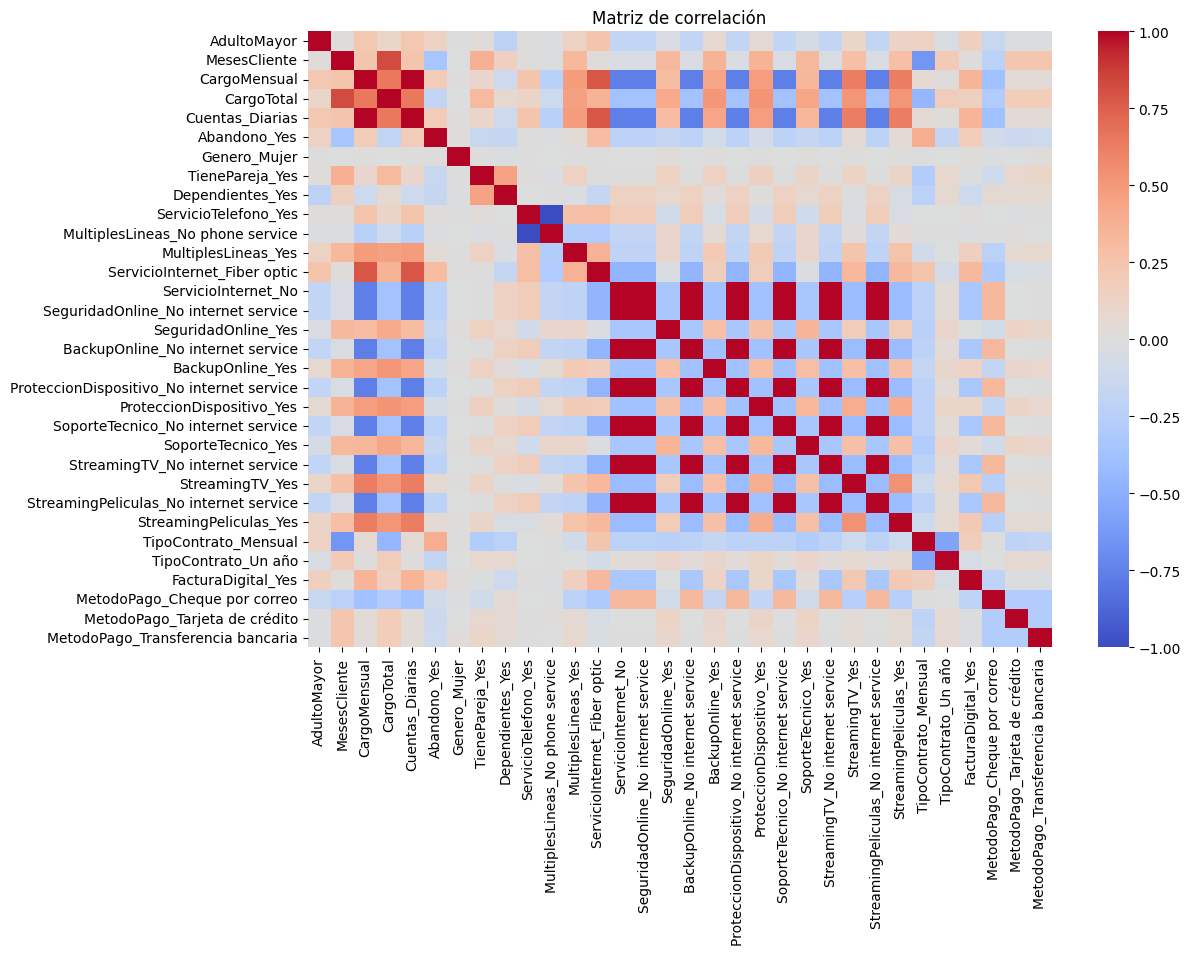

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Matriz de correlación")
plt.show()

In [15]:
df.corr()["Abandono_Yes"].sort_values(ascending=False)

,Abandono_Yes
Abandono_Yes,1.000000
TipoContrato_Mensual,0.395584
ServicioInternet_Fiber optic,0.300949
CargoMensual,0.189866
Cuentas_Diarias,0.189866
FacturaDigital_Yes,0.186666
AdultoMayor,0.146733
StreamingTV_Yes,0.062430
StreamingPeliculas_Yes,0.060586
MultiplesLineas_Yes,0.039343


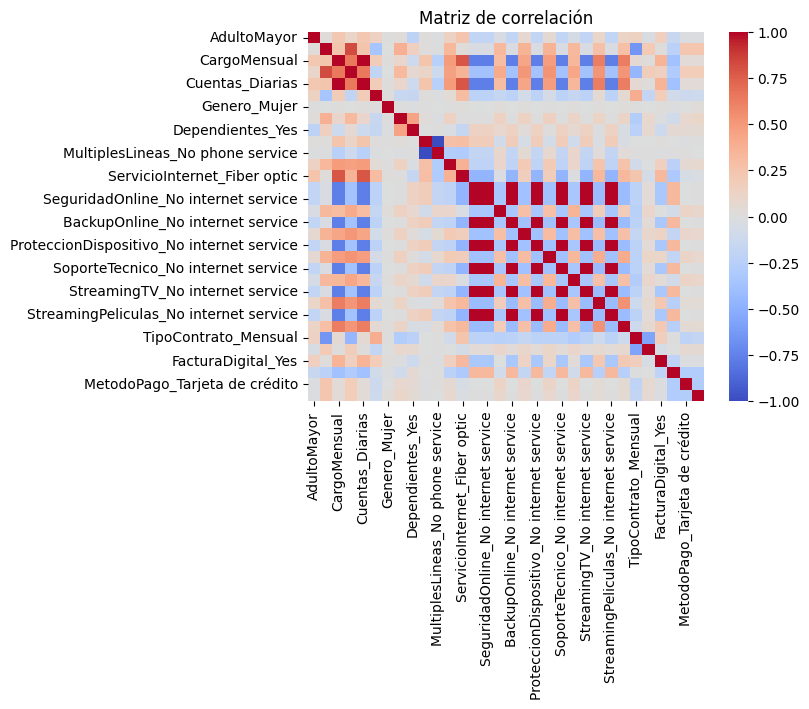

In [27]:
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

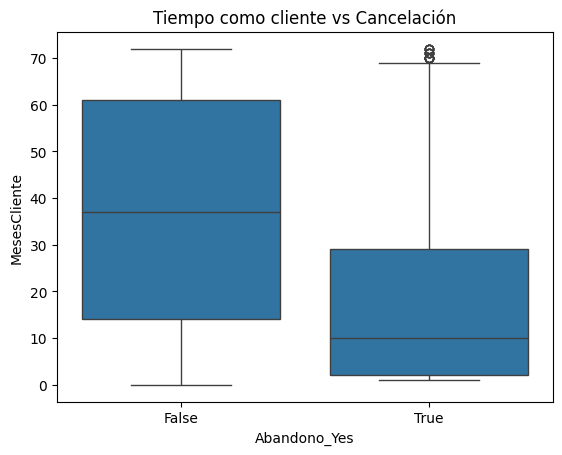

In [16]:
sns.boxplot(x="Abandono_Yes", y="MesesCliente", data=df)

plt.title("Tiempo como cliente vs Cancelación")
plt.show()

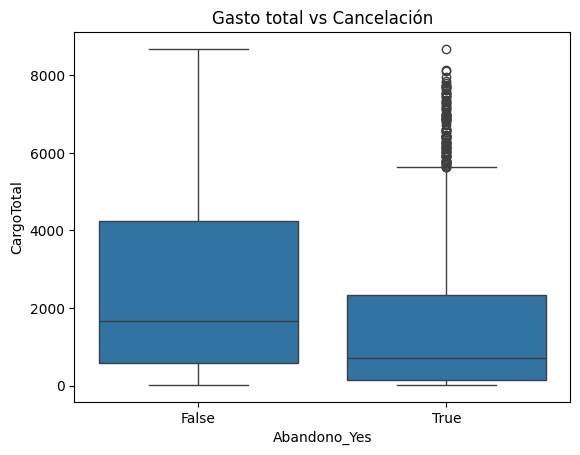

In [17]:
sns.boxplot(x="Abandono_Yes", y="CargoTotal", data=df)

plt.title("Gasto total vs Cancelación")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train_scaled, y_train)

y_pred_lr = modelo_lr.predict(X_test_scaled)

In [21]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [23]:
print("Regresión Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_lr))

Regresión Logística
Accuracy: 0.8149931224209078
Precision: 0.6710963455149501
Recall: 0.543010752688172
F1-score: 0.600297176820208
Matriz de confusión:
[[983  99]
 [170 202]]


In [24]:
print("Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
Accuracy: 0.7916093535075653
Precision: 0.6169491525423729
Recall: 0.489247311827957
F1-score: 0.545727136431784
Matriz de confusión:
[[969 113]
 [190 182]]


In [25]:
import pandas as pd

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_lr.coef_[0]
})

coeficientes.sort_values(by="Coeficiente", ascending=False).head(10)

,Variable,Coeficiente
3,CargoTotal,0.826885
25,TipoContrato_Mensual,0.686669
11,ServicioInternet_Fiber optic,0.487232
26,TipoContrato_Un año,0.286688
24,StreamingPeliculas_Yes,0.182199
27,FacturaDigital_Yes,0.159330
22,StreamingTV_Yes,0.140029
10,MultiplesLineas_Yes,0.133253
0,AdultoMayor,0.078011
9,MultiplesLineas_No phone service,0.031988


In [26]:
import pandas as pd

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias.sort_values(by="Importancia", ascending=False).head(10)

,Variable,Importancia
3,CargoTotal,0.170333
1,MesesCliente,0.153271
2,CargoMensual,0.132004
4,Cuentas_Diarias,0.130962
25,TipoContrato_Mensual,0.055665
11,ServicioInternet_Fiber optic,0.031139
5,Genero_Mujer,0.024536
27,FacturaDigital_Yes,0.023557
20,SoporteTecnico_Yes,0.022104
14,SeguridadOnline_Yes,0.021759


**Conclusión**
En la Regresión Logística se observaron los coeficientes de las variables para identificar cuáles tienen mayor influencia en la probabilidad de cancelación. En el caso de Random Forest se utilizó la métrica de importancia de variables para identificar cuáles contribuyen más a las decisiones del modelo.
Entre las variables más relevantes se encuentran el tipo de contrato, el tiempo como cliente y los cargos mensuales. Estas variables parecen tener una mayor relación con la cancelación del servicio.


**Conclusiones**
El anlisis muestra que factores como el tipo de contrato, el tiempo que el cliente lleva en la empresa y el costo del servicio pueden influir en la cancelación.
Los clientes con contratos mensuales y menor tiempo como clientes presentan mayor probabilidad de abandono.

**Recomendaciones**
Como estrategia de retención se podrían promover contratos de mayor duración y desarrollar acciones para fidelizar a los clientes nuevos durante sus primeros meses en el servicio.
También sería útil analizar más en detalle a los clientes con mayores cargos mensuales para identificar posibles mejoras en el servicio o en la estructura de precios.